In [1]:
# import cdsapi

# dataset = "reanalysis-era5-pressure-levels-monthly-means"
# request = {
#     "product_type": ["monthly_averaged_reanalysis"],
#     "variable": [
#         "u_component_of_wind",
#         "v_component_of_wind"
#     ],
#     "pressure_level": ["850"],
#     "year": [
#         "2001", "2002", "2003",
#         "2004", "2005", "2006",
#         "2007", "2008", "2009",
#         "2010", "2011", "2012",
#         "2013", "2014", "2015",
#         "2016", "2017", "2018"
#     ],
#     "month": [
#         "01", "02", "03",
#         "04", "05", "06",
#         "07", "08", "09",
#         "10", "11", "12"
#     ],
#     "time": ["00:00"],
#     "data_format": "netcdf",
#     "download_format": "zip"
# }

# client = cdsapi.Client()
# client.retrieve(dataset, request).download()


2025-06-06 15:26:47,901 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-06-06 15:26:48,420 INFO Request ID is cbffbdfd-6a28-40fe-8d5f-aea40e328dc0
2025-06-06 15:26:48,543 INFO status has been updated to accepted
2025-06-06 15:26:57,165 INFO status has been updated to successful


7404264d3cd5fd45348a08dedbf6393b.zip:   0%|          | 0.00/738M [00:00<?, ?B/s]

'7404264d3cd5fd45348a08dedbf6393b.zip'

In [6]:
# import glob
# import xarray as xr
# years = range(2001, 2019)  # 2019 不包含，所以是 2001-2018

# # 生成文件路径列表
# file_paths = [
#     f"/Net/Groups/data_BGC/era5/e1/0d50_monthly/tp/tp.monthly.fc.era5.720.360.{year}.nc"
#     for year in years
# ]
# datasets = [xr.open_dataset(f).tp.isel(time=1) for f in file_paths]
# ds = xr.concat(datasets, dim="time") 
# avg = ds.mean(dim='time')
# avg.to_netcdf("era5_tp_january_avg_2001-2018_1d00.nc")#july

In [8]:
# import xarray as xr
# dat=xr.open_dataset('era5_850hpa_wind_1d00_monthly.nc')
# u1= dat.u.groupby('valid_time.month').mean(dim = 'valid_time').sel(month=7).load()
# v1= dat.v.groupby('valid_time.month').mean(dim = 'valid_time').sel(month=7).load()
# v1.to_netcdf("era5_v1_july_avg_2001-2018_1d00.nc")
# u1.to_netcdf("era5_u1_july_avg_2001-2018_1d00.nc")

In [1]:
def sea_mask():
    # Load natural Earth land dataset using geopandas
    land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    # Optionally exclude Antarctica from the land dataset
    land = land[land['continent'] != 'Antarctica']
    
    # Create a transform object for coordinate transformation
    # based on the spatial extent and resolution of dataset tp1
    transform = rasterio.transform.from_origin(
        tp1.longitude.min(), tp1.latitude.max(),
        (tp1.longitude.max() - tp1.longitude.min()) / len(tp1.longitude),
        (tp1.latitude.max() - tp1.latitude.min()) / len(tp1.latitude))
    
    # Create a boolean mask where True represents land areas
    # and False represents ocean areas
    mask = geometry_mask(
        land.geometry,  # Use land geometries to create the mask
        out_shape=(len(tp1.latitude), len(tp1.longitude)),  # Output shape matches tp1 dimensions
        transform=transform,  # Coordinate transformation
        invert=True  # True=land areas, False=ocean areas
    )
    
    return mask

# The following commented code shows potential usage examples:
# tp1_land = np.where(mask, tp1.tp.values, np.nan)  # Apply mask to tp1 data
# 
# # Example plotting code (commented out)
# im = ax.pcolormesh(
#     tp1.longitude, tp1.latitude, tp1_land,
#     cmap='lapaz_r',
#     transform=ccrs.PlateCarree(),
#     vmin=0,
#     vmax=500
# )

In [6]:
import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd

import matplotlib.pyplot as plt
# Some defaults:
#plt.rcParams['figure.figsize'] = (12, 5)  # Default plot size
import numpy as np  # numerical library
np.set_printoptions(threshold=20)  # avoid to print very large arrays on screen
# The commands below are to ignore certain warnings.
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt  # plotting library

import xarray as xr  # netCDF library
import cartopy  # Map projections libary, needed to display world maps
import cartopy.crs as ccrs  # Projections list
import logging

import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [7]:
lonlim = (-82, -32)
latlim = (-60, 15)

In [8]:
# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

In [9]:
# Set scaling factor for data resolution reduction
scale = 10

# Load January wind component datasets (U and V) from NetCDF files
v1 = xr.open_dataset("era5_v1_january_avg_2001-2018_1d00.nc")
u1 = xr.open_dataset("era5_u1_january_avg_2001-2018_1d00.nc")

# Extract and downsample 850 hPa wind components for January
pu1 = u1.u.sel(pressure_level=850)[::scale, ::scale]  # Zonal wind component
pv1 = v1.v.sel(pressure_level=850)[::scale, ::scale]  # Meridional wind component

# Load July wind component datasets (U and V) from NetCDF files
v7 = xr.open_dataset("era5_v1_july_avg_2001-2018_1d00.nc")
u7 = xr.open_dataset("era5_u1_july_avg_2001-2018_1d00.nc")

# Extract and downsample 850 hPa wind components for July
pu7 = u7.u.sel(pressure_level=850)[::scale, ::scale]  # Zonal wind component
pv7 = v7.v.sel(pressure_level=850)[::scale, ::scale]  # Meridional wind component

In [10]:
tp1=xr.open_dataset("era5_tp_january_avg_2001-2018_1d00.nc")
tp7=xr.open_dataset("era5_tp_july_avg_2001-2018_1d00.nc")

In [ ]:
# Turn off interactive plotting mode
plt.ioff()
# Adjust bottom margin to make space for colorbar
plt.subplots_adjust(bottom=0.5)
# Define map projection
proj = ccrs.PlateCarree()

# Define subplot arrangement (2x2 grid with empty bottom row)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2],
    [0, 0]
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, height_ratios=[6, 1], width_ratios=[1, 1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

################################################
# First subplot (January data)
ax = axs[0]

# Apply land mask to precipitation data (tp1)
tp1_land = np.where(sea_mask(), tp1.tp.values, np.nan)
# Plot precipitation data as colormesh
im = ax.pcolormesh(tp1.longitude, tp1.latitude, tp1_land,
                 cmap='lapaz_r',
                 discrete=False,
                 transform=ccrs.PlateCarree(), vmin=0, vmax=500)

# Plot wind vectors as quiver plot for January
qv = ax.quiver(pu1.longitude, pu1.latitude, pu1, pv1, transform=ccrs.PlateCarree(), 
               vmin=0, vmax=15, color='grey',
               scale=50,  # Adjust arrow size (smaller value = larger arrows)
               width=0.005)  # Arrow width

# Plot Amazon border and Andes mountain range
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', 
                                                          linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Second subplot (July data)
ax = axs[1]

# Plot Amazon border and Andes mountain range
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', 
                                                          linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Apply land mask to precipitation data (tp7)
tp7_land = np.where(sea_mask(), tp7.tp.values, np.nan)
# Plot precipitation data as colormesh
im = ax.pcolormesh(tp7.longitude, tp7.latitude, tp7_land,
                 cmap='lapaz_r',
                 discrete=False,
                 transform=ccrs.PlateCarree(), vmin=0, vmax=500)

# Create colorbar axis below the plots
cax = fig.add_axes([0.3, 0.045, 0.4, 0.02], title='Averaged monthly precipitation (mm/month)', titlesize=10)
# Add colorbar to the figure
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='max',
    ticks=[0, 250, 500],
)

# Plot wind vectors as quiver plot for July
qv = ax.quiver(pu7.longitude, pu7.latitude, pu7, pv7, transform=ccrs.PlateCarree(), 
               vmin=0, vmax=15, color='grey',
               scale=50,  # Adjust arrow size (smaller value = larger arrows)
               width=0.005)  # Arrow width

# Create quiver key for wind scale
handles = [ax.quiverkey(qv, 0, -0.04, 10, label='10 m/s', labelpos='E')]

# Adjust layout and display/save figure
plt.tight_layout()
plt.show()
# Save figure as high-resolution TIFF
plt.savefig('figs_wind.tiff', dpi=300)

<Figure size 640x440 with 0 Axes>

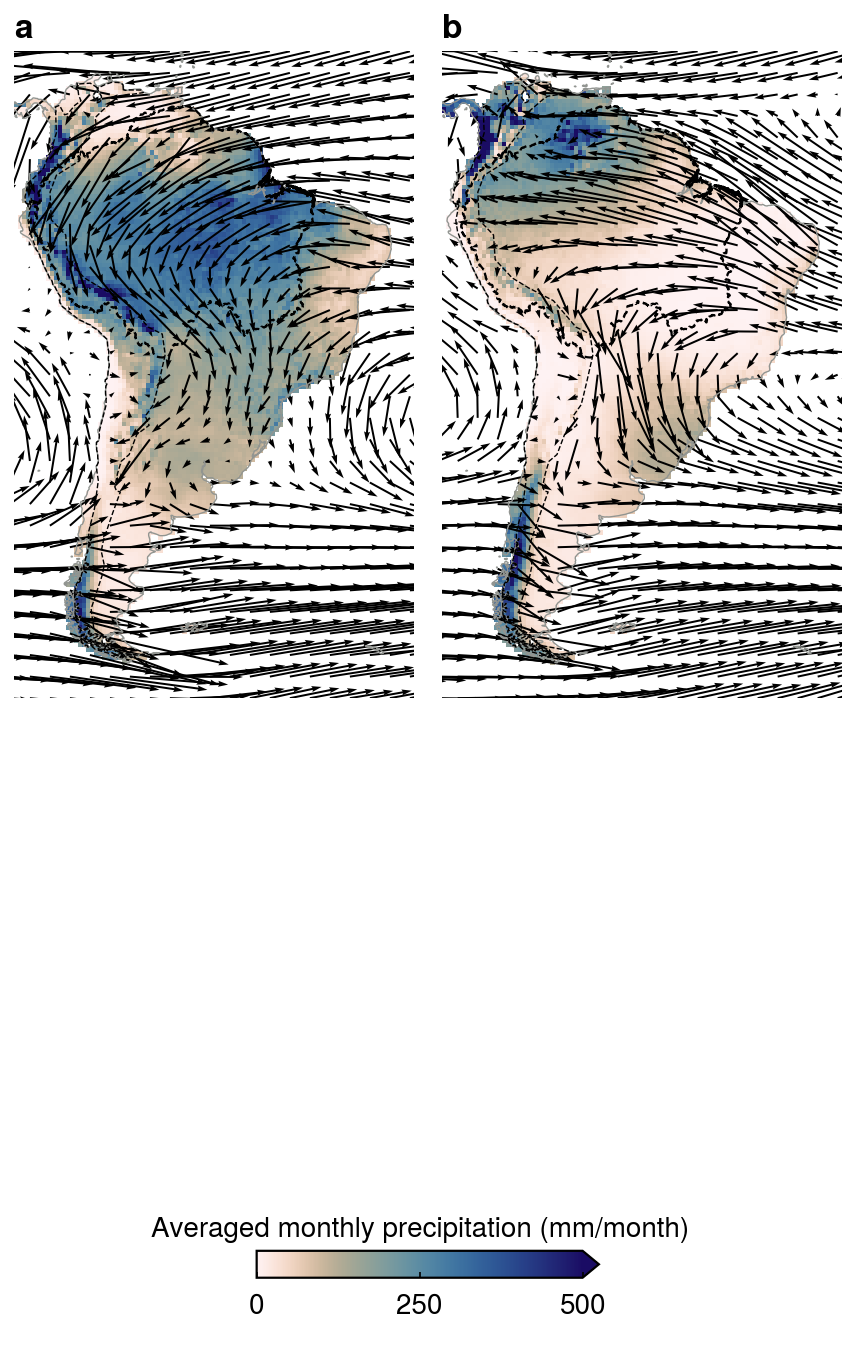

In [115]:
# Turn off interactive plotting mode
plt.ioff()
# Define map projection
proj = ccrs.PlateCarree()

# Define subplot arrangement (2x2 grid with empty bottom row)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2],
    [0, 0]
]

# Create figure with modified parameters to remove surrounding whitespace
fig = uplt.figure(refwidth=2, share=False, span=False, 
                 tight=True, frameon=False,  # Remove figure frame
                 constrained_layout=True)  # Use constrained layout

# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, 
                  height_ratios=[1], width_ratios=[1, 1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

################################################
# First subplot (January data)
ax = axs[0]

# Apply land mask to precipitation data (tp1)
tp1_land = np.where(sea_mask(), tp1.tp.values, np.nan)
# Plot precipitation data as colormesh
im = ax.pcolormesh(tp1.longitude, tp1.latitude, tp1_land,
               cmap='lapaz_r',
               discrete=False,
               transform=ccrs.PlateCarree(), vmin=0, vmax=500)

# Plot wind vectors as quiver plot for January
qv = ax.quiver(pu1.longitude, pu1.latitude, pu1, pv1, 
              transform=ccrs.PlateCarree(), vmin=0, vmax=15,
              scale=50, width=0.005)

# Plot Amazon border and Andes mountain range
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Second subplot (July data)
ax = axs[1]

# Plot Amazon border and Andes mountain range
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Apply land mask to precipitation data (tp7)
tp7_land = np.where(sea_mask(), tp7.tp.values, np.nan)
# Plot precipitation data as colormesh
im = ax.pcolormesh(tp7.longitude, tp7.latitude, tp7_land,
               cmap='lapaz_r',
               discrete=False,
               transform=ccrs.PlateCarree(), vmin=0, vmax=500)

# Adjust colorbar position and add to figure
cax = fig.add_axes([0.3, 0.05, 0.4, 0.02], 
                 title='Averaged monthly precipitation (mm/month)', 
                 titlesize=10)
fig.colorbar(im, cax=cax, orientation='horizontal',
            extend='max', ticks=[0, 250, 500])

# Plot wind vectors as quiver plot for July
qv = ax.quiver(pu7.longitude, pu7.latitude, pu7, pv7, 
              transform=ccrs.PlateCarree(), vmin=0, vmax=15,
              scale=50, width=0.005)

# Apply tight layout with adjusted padding parameters
plt.tight_layout(pad=0.1, h_pad=0.1, w_pad=0.1)
# Manually adjust subplot positions for optimal spacing
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9)

# Display the final figure
plt.show()

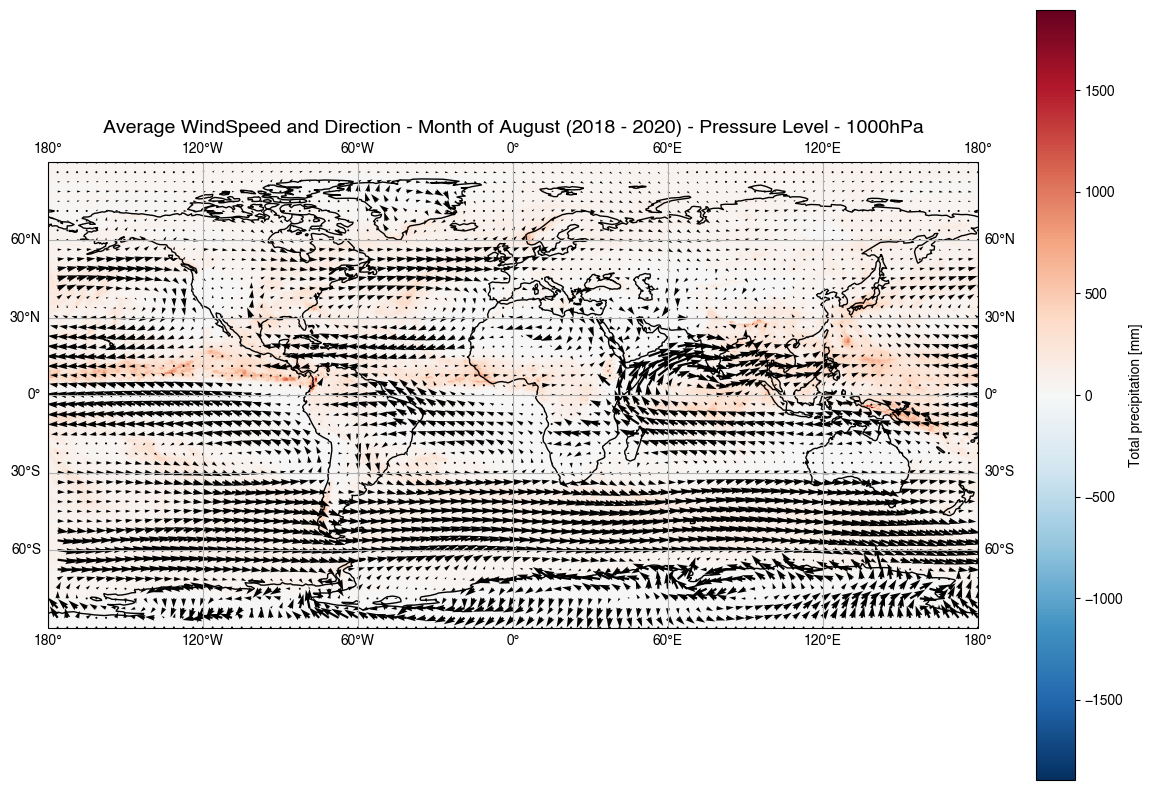

In [40]:
# Create a figure with specified size
fig = plt.figure(figsize=(15, 10))
# Create a geographic axes with PlateCarree projection
ax = plt.axes(projection=ccrs.PlateCarree())  

# Extract and downsample 850 hPa wind components (every 15th data point)
pu, pv = u8.sel(pressure_level=850)[::15, ::15], v8.sel(pressure_level=850)[::15, ::15]  

# Plot precipitation data for the 8th time step
tpv.tp.isel(time=8).plot(ax=ax)

# Plot wind vectors as quiver plot
qv = ax.quiver(pu.longitude, pu.latitude, pu, pv, transform=ccrs.PlateCarree())

# Add coastlines with black color
ax.coastlines(color='black')

# Set plot title with specified font size
plt.title('Average WindSpeed and Direction - Month of August (2018 - 2020) - Pressure Level - 1000hPa',
         fontsize=14)

# Add gridlines with latitude/longitude labels
ax.gridlines(draw_labels=True)